## Reduction with tsample algorithm  
We compare MovingPandas and MobilityPandas (which uses PyMEOS) libraries.

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from shapely.geometry import Point

from geopandas import GeoDataFrame
import zipfile

import sys
sys.path.append("../..") # so we use MobilityPandas 
import movingpandas as mpd

import warnings
import numpy as np
warnings.simplefilter("ignore")
from pyproj import Transformer
from datetime import timedelta

import pymeos
from pymeos import TGeomPointSeq
pymeos.pymeos_initialize()

HAS_PYMEOS =  True


We use AIS data.

In [2]:
zip_path = 'data/aisdk-2025-07-11.zip'
csv_filename = 'aisdk-2025-07-11.csv'

sizes = {'small': 100000, 'medium': 1000000, 'large': 5000000}
chosen_size = 'small'

In [3]:
def extraction():
    global df
    with zipfile.ZipFile(zip_path) as archive:        
        with archive.open(csv_filename) as file:
            df = pd.read_csv(file, usecols=['# Timestamp', 'MMSI', 'Latitude', 'Longitude'], nrows=sizes[chosen_size])

    df.rename(columns={'# Timestamp': 't', 'MMSI': 'mmsi', 'Latitude': 'lat', 'Longitude': 'lon'}, inplace=True)
    df = df[df['lat'] <= 90] # default latitude = 91°
    df = df.sort_values(['mmsi', 't'])
    df = df.drop_duplicates(subset=['mmsi', 't'], keep='last')

    transformer = Transformer.from_crs("EPSG:4326", "EPSG:25832", always_xy=True)

    df[['x', 'y']] = df.apply(
        lambda row: pd.Series(transformer.transform(row['lon'], row['lat'])),
        axis=1
    )
    df.drop(columns=['lat', 'lon'])

    global nb_points
    nb_points = df.shape[0]

# extraction()

## MovingPandas (without PyMEOS)

In [4]:
def construction_without():
    df1 = df.copy()
    df1['geometry'] = [Point(x, y) for x, y in zip(df1['x'], df1['y'])]
    gdf = GeoDataFrame(df1, geometry='geometry')
    gdf.set_crs(epsg=25832, inplace=True)
    gdf['t'] = pd.to_datetime(gdf['t'])

    global trajectories_without
    trajectories_without = gdf

# construction_without()

## MobilityPandas (with PyMEOS)
We use `from_arrays` method.

In [5]:
def construction_with():

    df3 = df.copy()
    df3['t'] = pd.to_datetime(df3['t'])

    global trajectories_with
    tr = (df3.groupby('mmsi')
        .apply(lambda traj: TGeomPointSeq.from_arrays(
            t = traj['t'].dt.strftime('%Y-%m-%d %H:%M:%S').values,
            x = traj['x'].values, 
            y = traj['y'].values,
            srid = 25832,
            upper_inc=True,
        ))
        .rename('trajectory')
    ).to_frame()

    trajectories_with = tr['trajectory'].apply(
        lambda seq: TGeomPointSeq.from_instants(seq.instants(), upper_inc=True)
    ).to_frame(name='trajectory')

# construction_with()

## Reduction

In [6]:
def reduce_with():
    global reduced_with
    reduced_with = trajectories_with.trajectory.apply(
        lambda x: x.temporal_sample(duration=timedelta(minutes=1), start=x.start_timestamp())
    )

# reduce_with()

In [7]:
def reduce_without():
    sampled_trajectories = []

    for mmsi, group in trajectories_without.groupby('mmsi'):
        group = group.sort_values('t').set_index('t')

        # Downsampling, keeping th first point of each interval
        gdf_downsampled = group.resample(timedelta(minutes=1)).first().dropna(subset=['geometry'])

        # Add the last point
        last_point = group.iloc[-1:]
        if last_point.index[0] not in gdf_downsampled.index:
            gdf_downsampled = pd.concat([gdf_downsampled, last_point])

        if len(gdf_downsampled) > 1:
            sampled_trajectories.append(mpd.Trajectory(gdf_downsampled, mmsi))

    global reduced_without
    reduced_without = mpd.TrajectoryCollection(sampled_trajectories)

# reduce_without()

## Measures

In [8]:
import time
from memory_profiler import memory_usage
results = {}

def mem_and_cpu_time(f, n=4):

    mem_usage = memory_usage((f), interval=0.01)
    mem_used = max(mem_usage) - min(mem_usage)

    times = []
    for _ in range(n):
        start = time.process_time()
        f()
        end = time.process_time()

        cpu_time = end - start
        times.append(cpu_time)

    times.pop(times.index(max(times)))
    times.pop(times.index(min(times)))
    mean_t = np.mean(times)
    std_t = np.std(times)
    results[f.__name__] = (mean_t, mem_used)
    # results[f.__name__] = (mean_t, 0)  # if you don't want to calculate memory usage


    print(f"Function {f.__name__}:")
    print(f"CPU time over {n} runs: {mean_t:.6f} sec ± {std_t:.6f} sec")
    print(f"Memory usage : {mem_used:.2f} MiB\n")


extraction()
construction_with()
mem_and_cpu_time(construction_without)
mem_and_cpu_time(reduce_without)
mem_and_cpu_time(reduce_with)

Function construction_without:
CPU time over 4 runs: 0.289581 sec ± 0.081051 sec
Memory usage : 7.12 MiB

Function reduce_without:
CPU time over 4 runs: 15.181851 sec ± 0.298907 sec
Memory usage : 26.50 MiB

Function reduce_with:
CPU time over 4 runs: 0.245578 sec ± 0.001789 sec
Memory usage : 0.12 MiB



In [9]:
# extraction()
# construction_without()
# construction_with()
# reduce_without()
# reduce_with()

add data from the construction benchmark

In [10]:
if chosen_size == 'small':
    results['extraction'] = (3.907518819249997, 112.05859375)
    # results['construction_without'] = (3.0670779807500033, 2.25)
    results['construction_with'] = (1.1410889672500026, 1.0)

elif chosen_size == 'medium':
    results['extraction'] = (36.63349021150001, 1043.78515625)
    # results['construction_without'] = (8.769085886750005, 67.4765625)
    results['construction_with'] = (3.2806865339999973, 0.0)

elif chosen_size == 'large':
    results['extraction'] = (164.43046756125, 5062.60546875)
    # results['construction_without'] = (20.915836654249972, 433.7890625)
    results['construction_with'] = (10.292904473250076, 2.0)

else:
    raise Exception("Chosen size must be small, medium or large")


# Performance measures

## Reduction

In [11]:
kept_points_without = 0
for traj in reduced_without.trajectories :
    kept_points_without += traj.size()

kept_points_with = 0
for traj in reduced_with :
    if traj:
        kept_points_with += traj.num_instants()

print("Percentage of points kept : (without pymeos, with pymeos)")
print(np.round(kept_points_without*100/nb_points, 2), '%,  ',
      np.round(kept_points_with*100/nb_points, 2), '%,  ')


Percentage of points kept : (without pymeos, with pymeos)
40.06 %,   25.05 %,  


## Time and memory

### Calculation

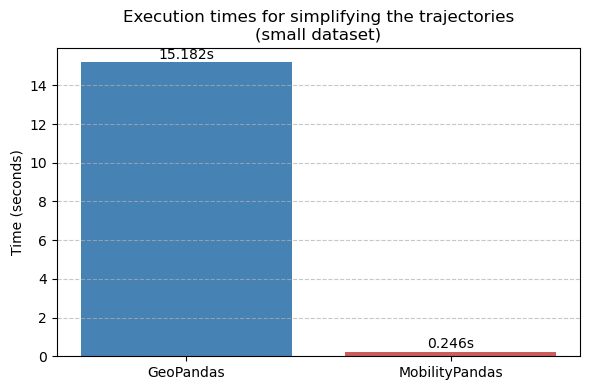

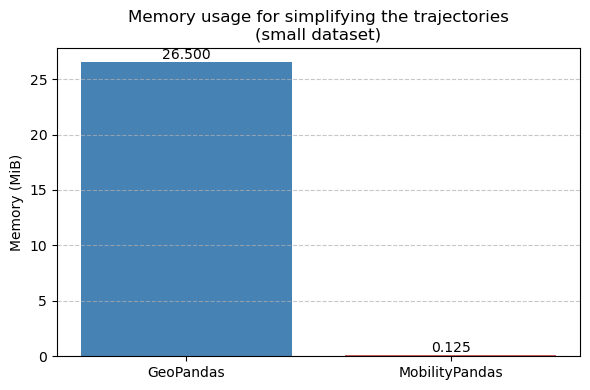

In [12]:
timesCa = [results['reduce_without'][0], results['reduce_with'][0]]
memCa = [results['reduce_without'][1], results['reduce_with'][1]]
libs = ['GeoPandas', 'MobilityPandas']

plt.figure(figsize=(6, 4))
bars = plt.bar(libs, timesCa, color=['steelblue', 'indianred'])
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.002, f"{yval:.3f}s", ha='center', va='bottom')

plt.title(f"Execution times for simplifying the trajectories\n({chosen_size} dataset)")
plt.ylabel("Time (seconds)")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
bars = plt.bar(libs, memCa, color=['steelblue', 'indianred'])
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.002, f"{yval:.3f}", ha='center', va='bottom')

plt.title(f"Memory usage for simplifying the trajectories\n({chosen_size} dataset)")
plt.ylabel("Memory (MiB)")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


### Complete process

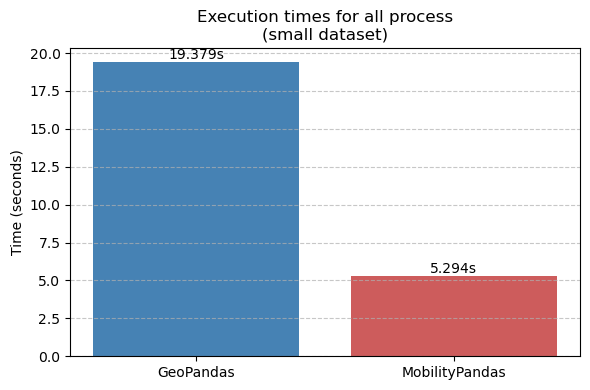

In [13]:
times = [results['extraction'][0] + results['construction_without'][0] + results['reduce_without'][0], 
         results['extraction'][0]+ results['construction_with'][0] + results['reduce_with'][0]]

plt.figure(figsize=(6, 4))
bars = plt.bar(libs, times, color=['steelblue', 'indianred'])
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.002, f"{yval:.3f}s", ha='center', va='bottom')

plt.title(f"Execution times for all process\n({chosen_size} dataset)")
plt.ylabel("Time (seconds)")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Preservation

### Total length of the trajectories

In [14]:
trajectories_without = mpd.TrajectoryCollection(trajectories_without, traj_id_col='mmsi', t='t')

list_of_mmsi = [traj.id for traj in trajectories_without]

diff_without, diff_with = [], []
for i in range(len(trajectories_without.trajectories)):
      m = list_of_mmsi[i]
      lo = round(trajectories_without.trajectories[i].get_length(), 2)
      lwithout = round(reduced_without.trajectories[i].get_length(), 2)

      diff_without.append(abs(lo-lwithout))
      if reduced_with[m]:
            diff_with.append(abs(lo-round(reduced_with[m].length(), 2)))

print(f"Maximum length difference without pymeos: {round(max(diff_without), 2)} m,   with pymeos: {round(max(diff_with), 2)} m")
print(f"Average length difference without pymeos: {round(np.mean(diff_without), 2)} m,   with pymeos: {round(np.mean(diff_with), 2)} m")

KeyError: 'key of type tuple not found and not a MultiIndex'

## Let see

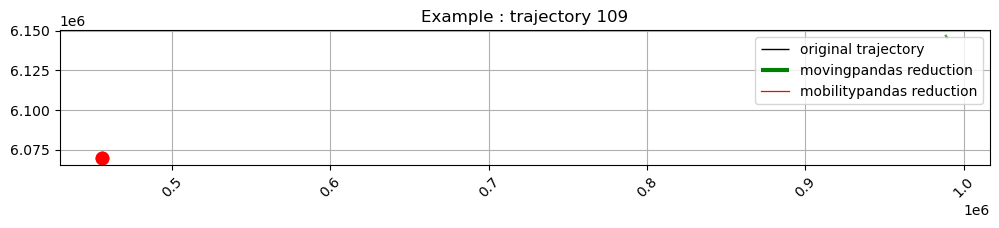

In [ ]:
# Plot one trajectory

n=109
m = [traj.id for traj in trajectories_without][n] # the corresponding MMSI

fig, ax = plt.subplots(figsize=(12, 8))
trajectories_without.trajectories[n].plot(color='black', label='original trajectory', linewidth=1, ax=ax)
reduced_without.trajectories[n].plot(color='green', label='movingpandas reduction', ax=ax, linewidth=3)
reduced_with[m].plot(color='red', label='mobilitypandas reduction', linewidth=0.9)

plt.title("Example : trajectory {0}".format(n))
plt.legend()
plt.show()